# Introduction to Pyro

In [251]:
import pyro
import torch
from pyro import distributions as dist
import matplotlib.pyplot as plt
import numpy as np
import random
import arviz as az
from pyro.infer import MCMC, NUTS, Predictive, EmpiricalMarginal
from pyro.infer.autoguide import init_to_mean, init_to_median, init_to_value
from pyro.infer.mcmc.util import summary

from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam

In [252]:
seed = 2026
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
pyro.set_rng_seed(seed)
torch.use_deterministic_algorithms(True)


In [253]:
# Parameters
a = pyro.param("a", torch.tensor(1.0))
b = pyro.param("b", torch.tensor([1.0, 2.0]))
a, b

(tensor(1., requires_grad=True), tensor([1., 2.], requires_grad=True))

In [254]:
# Samples
c = dist.Normal(0, 1).sample((5,))
d = dist.Normal(0, 1).expand([2]).sample((5,))
c, d

(tensor([ 0.3655,  1.9065,  0.2169,  0.2963, -1.0160]),
 tensor([[-0.6064,  0.1744],
         [-0.6306, -0.0954],
         [ 0.3191, -1.4710],
         [ 0.2610,  0.2796],
         [ 0.3426, -0.6132]]))

In [255]:
e = pyro.sample("e", dist.Normal(0, 1))
f = pyro.sample("f", dist.Normal(0, 1).expand([2]))
e,f

(tensor(-1.0022), tensor([ 0.1142, -2.0875]))

# Tossing a biased coin


In [256]:
true_p = 0.7
data = dist.Bernoulli(true_p).sample((100,))
data


tensor([0., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 0., 1., 0., 1., 0., 1., 1.,
        1., 1., 1., 1., 0., 0., 1., 0., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 0., 0., 0., 1., 1., 1.,
        0., 1., 0., 1., 1., 0., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1.,
        0., 0., 0., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1., 0., 0., 1., 1., 0.,
        0., 1., 1., 1., 1., 1., 1., 1., 1., 0.])

# Beta distribution
$$p(x; \alpha, \beta) = k * x^{\alpha -1} (1-x)^{\beta -1}$$

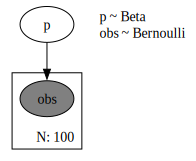

In [257]:
alpha_prior, beta_prior = 5.0, 1.0
def model(data):
    p = pyro.sample("p", dist.Beta(alpha_prior, beta_prior))
    
    with pyro.plate(f"N: {len(data)}", len(data)):
        pyro.sample("obs", dist.Bernoulli(p), obs=data)
        

pyro.render_model(model, model_args=(data,), render_distributions=True)

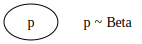

In [258]:
def guide(data):
    alpha = pyro.param("alpha", torch.tensor(alpha_prior), constraint=dist.constraints.positive)
    beta = pyro.param("beta", torch.tensor(beta_prior), constraint=dist.constraints.positive)
    pyro.sample("p", dist.Beta(alpha, beta))
    
pyro.render_model(guide, model_args=(data,), render_distributions=True)

In [259]:


optimizer = Adam({"lr": 1e-2})
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

losses = []
for step in range(1000):
    loss = svi.step(data)
    losses.append(loss)

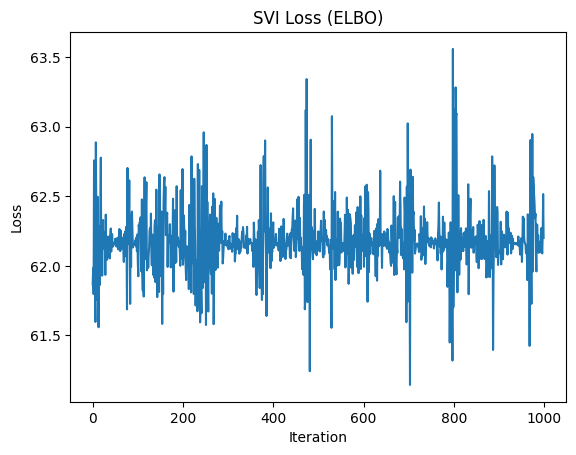

In [260]:
plt.plot(losses)
plt.title("SVI Loss (ELBO)")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

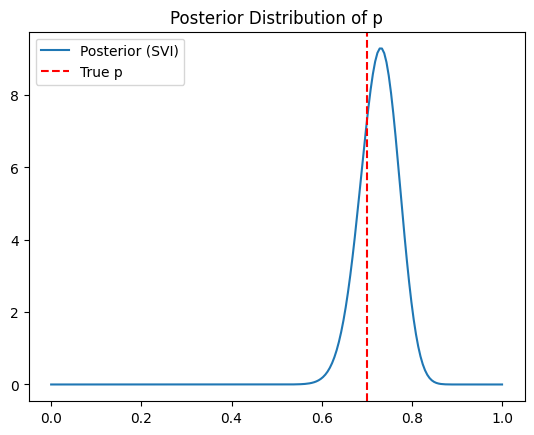

In [261]:
alpha = pyro.param("alpha").item()
beta = pyro.param("beta").item()

x = np.linspace(0, 1, 200)
posterior = dist.Beta(alpha, beta).log_prob(torch.tensor(x)).exp().numpy()

plt.plot(x, posterior, label="Posterior (SVI)")
plt.axvline(true_p, color='r', linestyle='--', label="True p")
plt.title("Posterior Distribution of p")
plt.legend()
plt.show()

In [262]:

prior_1 = Predictive(model,num_samples=1000)(data)
data_post_1 = az.from_pyro(prior=prior_1)

nuts_kernel = NUTS(model)
mcmc = MCMC(nuts_kernel, num_samples=1000, warmup_steps=200, num_chains=1)
mcmc.run(data)
samples_1 = mcmc.get_samples()
samples = samples_1["p"].numpy()

Sample: 100%|██████████| 1200/1200 [00:02, 414.60it/s, step size=1.62e+00, acc. prob=0.906]


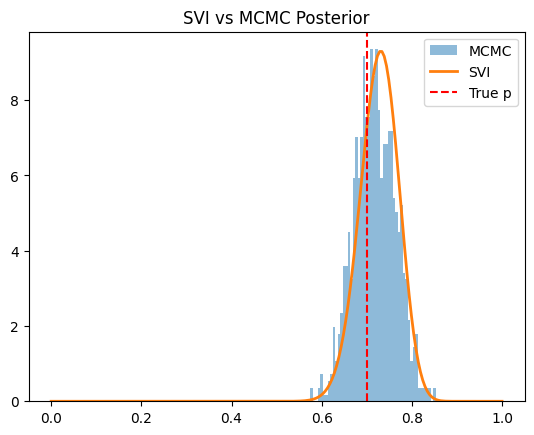

In [263]:
plt.hist(samples, bins=50, density=True, alpha=0.5, label="MCMC")

plt.plot(x, posterior, label="SVI", linewidth=2)
plt.axvline(true_p, color='r', linestyle='--', label="True p")

plt.legend()
plt.title("SVI vs MCMC Posterior")
plt.show()

array([[<Axes: title={'center': 'p'}>]], dtype=object)

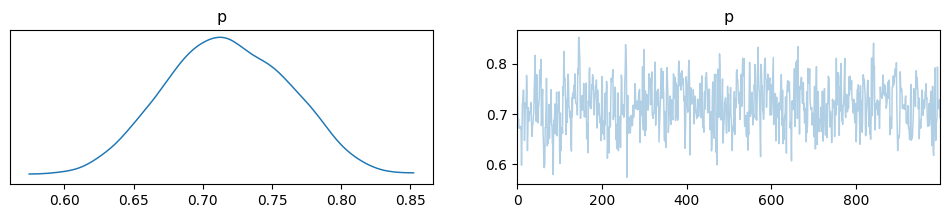

<Figure size 800x1000 with 0 Axes>

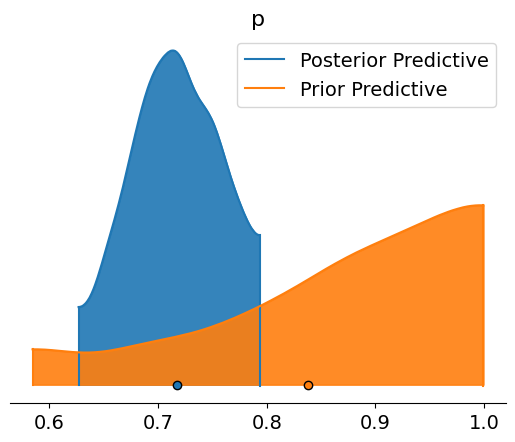

In [264]:
posterior_predictive_1 = Predictive(model, samples_1)(data)

data_post_1 = az.from_pyro(posterior=mcmc, prior=prior_1, posterior_predictive=posterior_predictive_1)
az.plot_trace(data_post_1)

plt.figure(figsize=(8,10))
az.plot_density(
data=[data_post_1.posterior, data_post_1.prior],
shade=.9,
var_names=['p'],
data_labels=["Posterior Predictive", "Prior Predictive"],
)


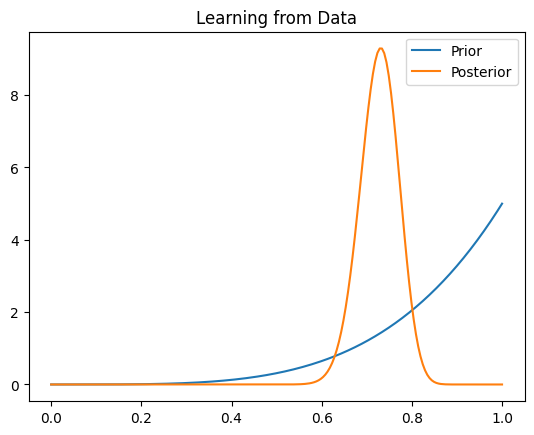

In [265]:
prior = dist.Beta(alpha_prior, beta_prior).log_prob(torch.tensor(x)).exp().numpy()

plt.plot(x, prior, label="Prior")
plt.plot(x, posterior, label="Posterior")
plt.legend()
plt.title("Learning from Data")
plt.show()

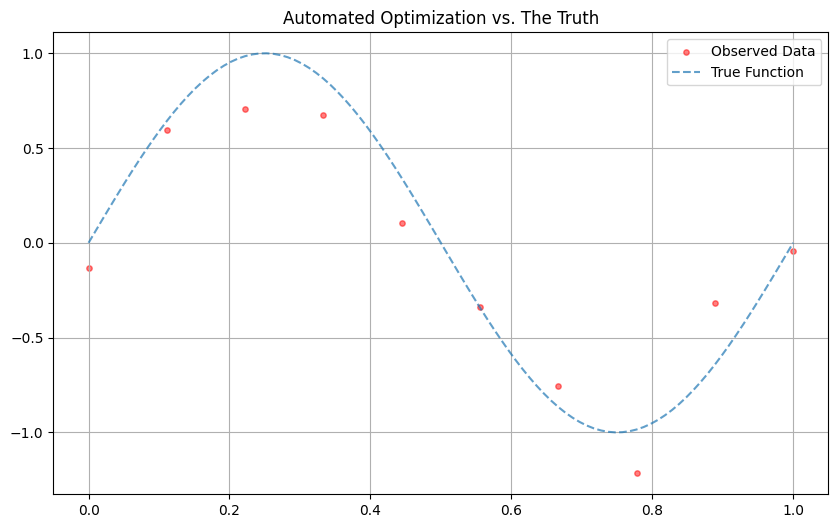

In [266]:
x = torch.linspace(0, 1, 10)
x_plot = torch.linspace(0, 1, 100)
y = torch.sin(2 * np.pi * x) 
y_true = torch.sin(2 * np.pi * x_plot)
noise = 0.2 * torch.randn_like(x)
y_obs = y + noise

plt.figure(figsize=(10, 6))
plt.scatter(x, y_obs, color='red', s=15, alpha=0.5, label="Observed Data")
plt.plot(x_plot, y_true, linestyle='--', alpha=0.7, label="True Function")

plt.title("Automated Optimization vs. The Truth")
plt.legend()
plt.grid(True)
plt.show()


In [267]:
# f(x; \theta) = \sum_{i=0}^{9} \theta_i x^i

def custom_function(x, coeff_poly):
    output =    coeff_poly[0] +\
                coeff_poly[1] * x +\
                coeff_poly[2] * x**2 +\
                coeff_poly[3] * x**3 +\
                coeff_poly[4] * x**4 +\
                coeff_poly[5] * x**5 +\
                coeff_poly[6] * x**6 +\
                coeff_poly[7] * x**7 +\
                coeff_poly[8] * x**8 +\
                coeff_poly[9] * x**9
    return output


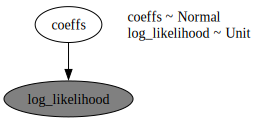

In [268]:
def model_poly(x, data):
    # We place a prior over the coefficients of the polynomial
    coeffs = pyro.sample("coeffs", dist.Normal(0, 5).expand([10]))
   
    # coeff_0 = pyro.sample("coeff_0", dist.Normal(0, 10))
    # coeff_1 = pyro.sample("coeff_1", dist.Normal(0, 10))
    # coeff_2 = pyro.sample("coeff_2", dist.Normal(0, 10))
    # coeff_3 = pyro.sample("coeff_3", dist.Normal(0, 10))
    # coeff_4 = pyro.sample("coeff_4", dist.Normal(0, 10))
    # coeff_5 = pyro.sample("coeff_5", dist.Normal(0, 10))
    # coeff_6 = pyro.sample("coeff_6", dist.Normal(0, 10))
    # coeff_7 = pyro.sample("coeff_7", dist.Normal(0, 10))
    # coeff_8 = pyro.sample("coeff_8", dist.Normal(0, 10))
    # coeff_9 = pyro.sample("coeff_9", dist.Normal(0, 10))
    # coeffs = torch.stack([coeff_0, coeff_1, coeff_2, coeff_3, coeff_4, coeff_5, coeff_6, coeff_7, coeff_8, coeff_9])
    
    # # We can also use deterministic to track the predicted values, but it is not necessary for inference
    # y_pred =    pyro.deterministic("y_pred", custom_function(x, coeffs))  
    
    y_pred =    custom_function(x, coeffs)
    
    
    
    # with pyro.plate("data", len(data)):
    #     pyro.sample("obs", dist.Normal(y_pred, 0.2), obs=data)
        
    log_likelihood = dist.Normal(y_pred, 0.05).log_prob(data)  # (N, K)
    # Always write pyro.factor outside the pyro plate, otherwise the likelihood will be multiplied with number of plate dim
    pyro.factor("log_likelihood", log_likelihood.sum())  # Scalar log joint 
    
    
pyro.render_model(model_poly, model_args=(x, y_obs,), render_distributions=True) # Args shoulb be a tuple


In [277]:
prior = Predictive(model_poly,num_samples=1000)(x,y_obs)
data_post = az.from_pyro(prior=prior)

nuts_kernel = NUTS(model_poly, step_size=0.0085, adapt_step_size=True, target_accept_prob=0.75, max_tree_depth=10, init_strategy=init_to_mean)
mcmc = MCMC(nuts_kernel, num_samples=200, warmup_steps=200, num_chains=1)
mcmc.run(x, y_obs)

samples = mcmc.get_samples()

Sample: 100%|██████████| 400/400 [04:49,  1.38it/s, step size=4.99e-03, acc. prob=0.920]


In [278]:
print("trace printing")
# Trace the model with the current sample values
import pyro.poutine as poutine

# Calculate the log joint (which includes log likelihood and log prior)
log_posterior_vals = []

for sample in zip(*samples.values()):  # Iterate over samples of all parameters
    # Set the current values for the model parameters
    sample_dict = {name: value for name, value in zip(samples.keys(), sample)}
    
    # Trace the model with the current sample values and the data as an argument
    # You need to use `sample_dict` to assign values to the model's random variables
    trace = poutine.trace(lambda: model_poly(x, y_obs)).get_trace()
    
    # Apply the sampled parameter values to the model trace
    for name, value in sample_dict.items():
        trace.nodes[name]["value"] = value  # Set the sampled values in the trace
    
    # we need to re run our model to update the value of node which are dependent on posterior sample
    replayed_model = poutine.replay(model_poly, trace=trace)
    trace = poutine.trace(replayed_model).get_trace(x, y_obs)
    # Calculate the log joint (which includes log likelihood and log prior)
    log_joint = trace.log_prob_sum()
    
    log_posterior_vals.append(log_joint.item())  # .item() to extract scalar from tensor

MAP_sample_index_trace = torch.argmax(torch.tensor(log_posterior_vals))
print("MAP_sample_index_trace\n", MAP_sample_index_trace)

trace printing
MAP_sample_index_trace
 tensor(100)


/Users/deepprakashravi/miniforge3/envs/gempy_dino/lib/python3.10/site-packages/arviz/data/io_pyro.py:158: UserWarning: Could not get vectorized trace, log_likelihood group will be omitted. Check your model vectorization or set log_likelihood=False
  warnings.warn(


array([[<Axes: title={'center': 'coeffs\n0'}>,
        <Axes: title={'center': 'coeffs\n1'}>,
        <Axes: title={'center': 'coeffs\n2'}>],
       [<Axes: title={'center': 'coeffs\n3'}>,
        <Axes: title={'center': 'coeffs\n4'}>,
        <Axes: title={'center': 'coeffs\n5'}>],
       [<Axes: title={'center': 'coeffs\n6'}>,
        <Axes: title={'center': 'coeffs\n7'}>,
        <Axes: title={'center': 'coeffs\n8'}>],
       [<Axes: title={'center': 'coeffs\n9'}>, <Axes: >, <Axes: >]],
      dtype=object)

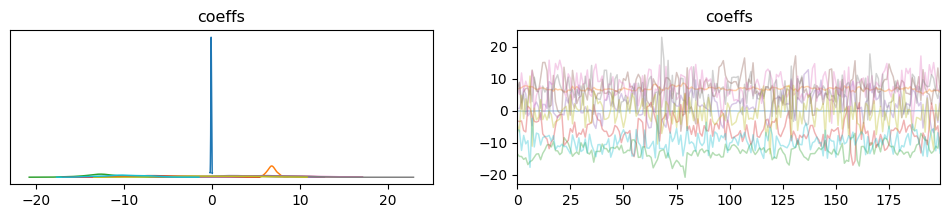

<Figure size 800x1000 with 0 Axes>

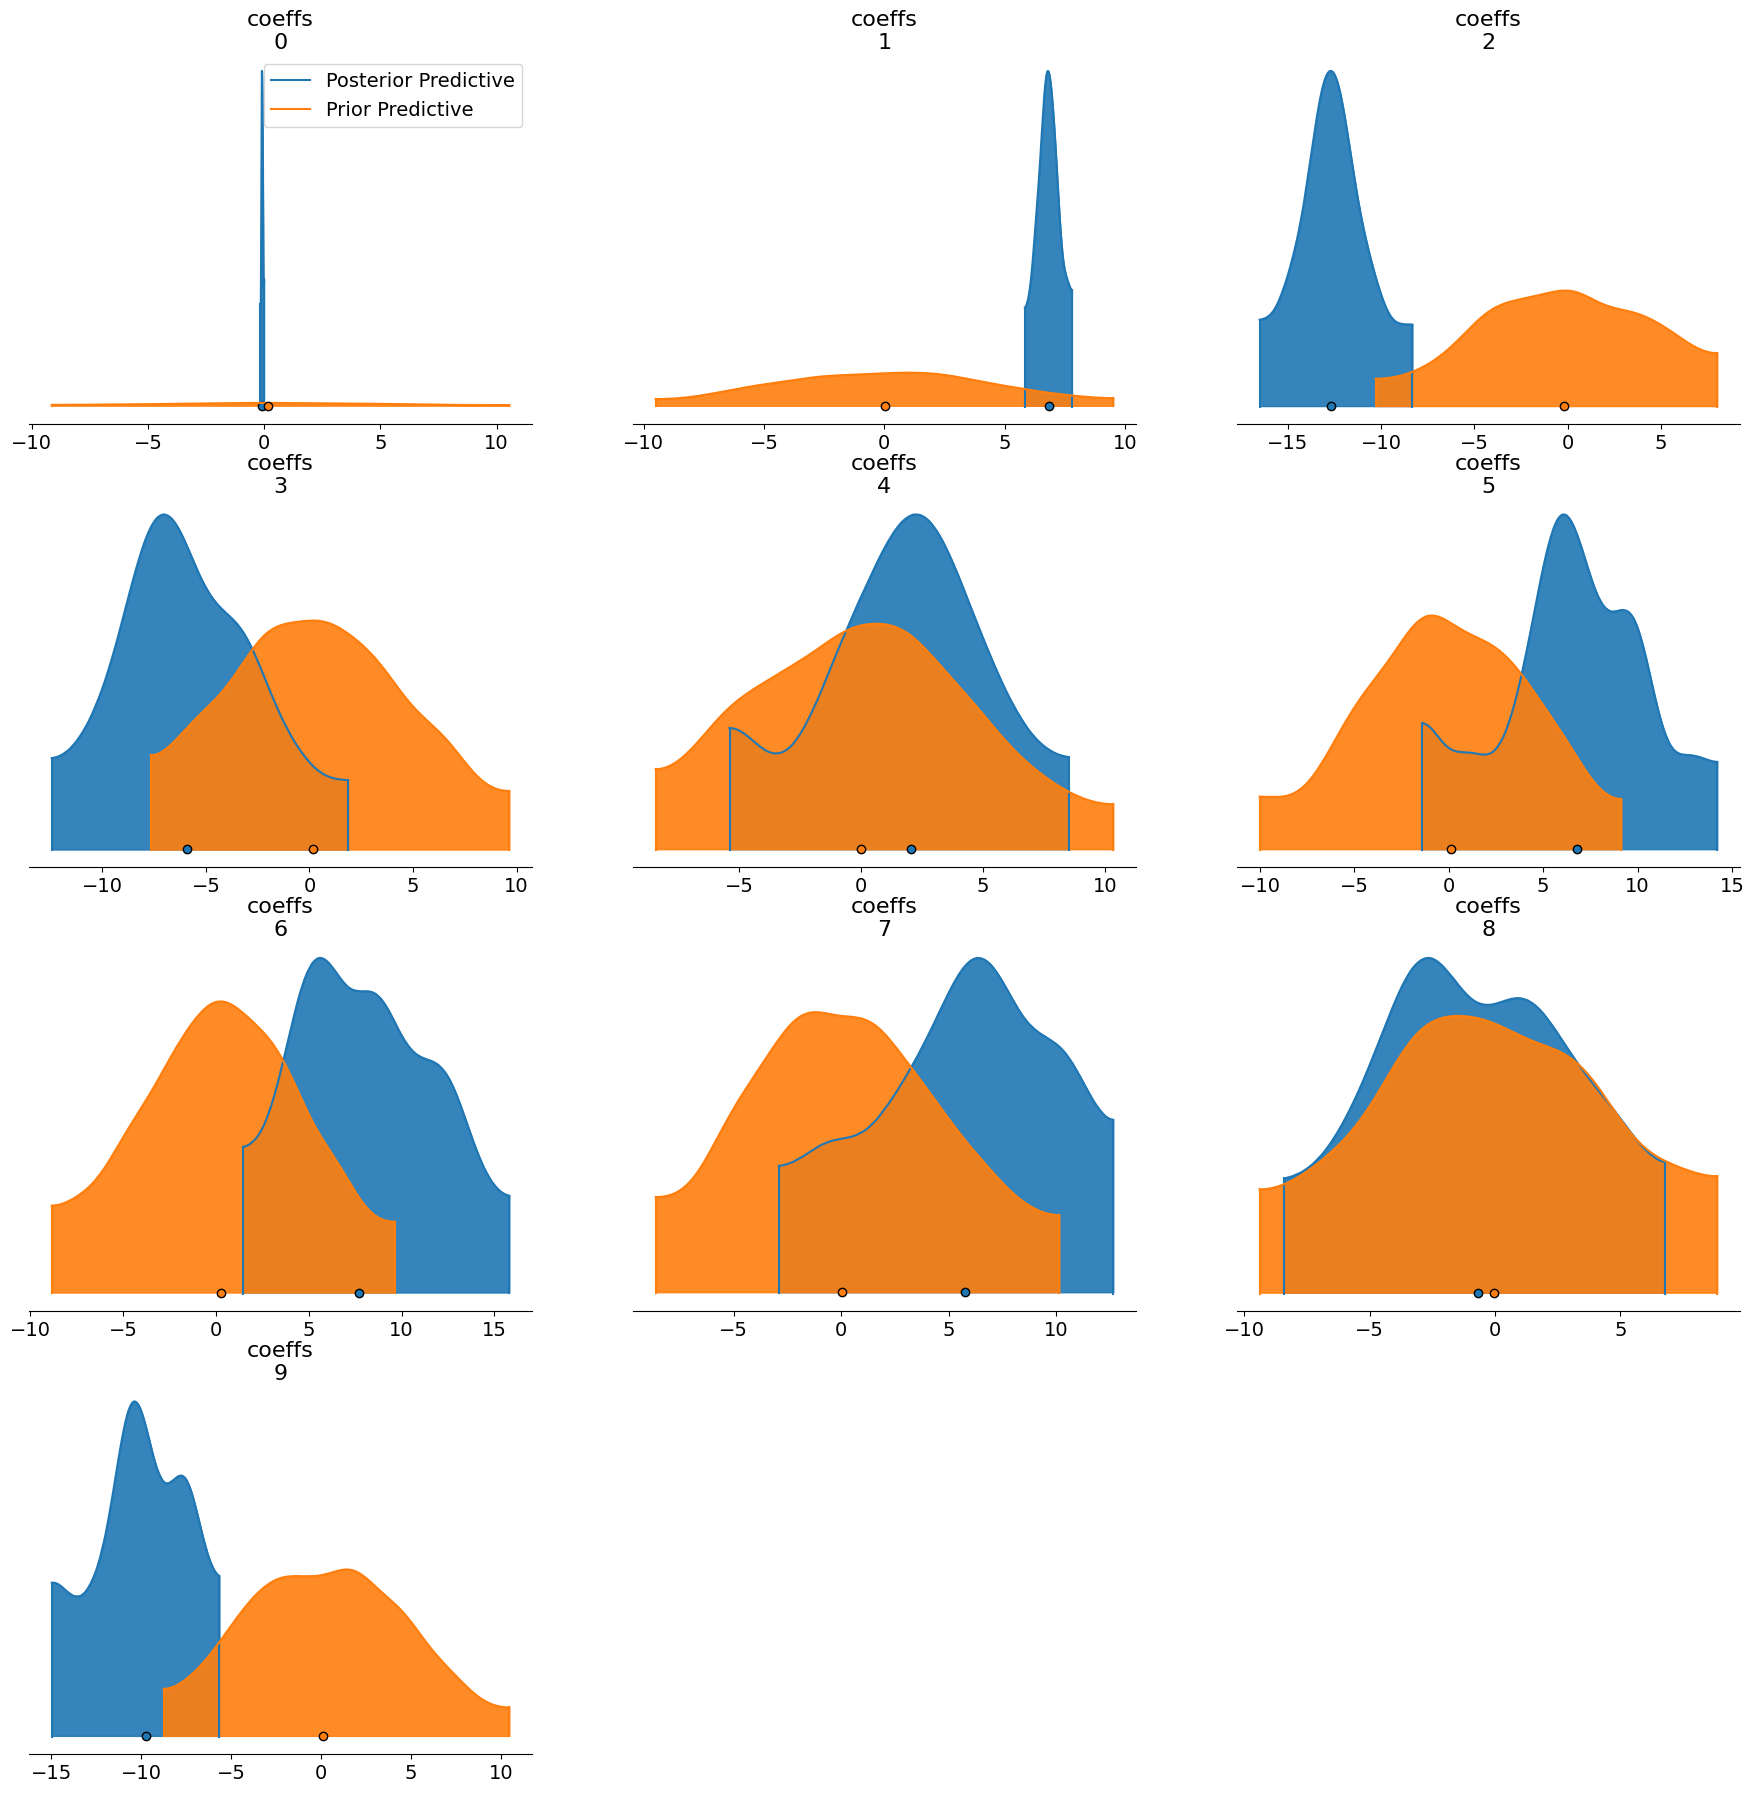

In [279]:
posterior_predictive = Predictive(model_poly, samples)(x, y_obs)

data_post = az.from_pyro(posterior=mcmc, prior=prior, posterior_predictive=posterior_predictive)
az.plot_trace(data_post)

plt.figure(figsize=(8,10))
az.plot_density(
data=[data_post.posterior, data_post.prior],
shade=.9,
var_names=['coeffs'],
data_labels=["Posterior Predictive", "Prior Predictive"],
)


In [280]:
samples_mean = samples["coeffs"].mean(axis=0)
samples_mean

tensor([ -0.0853,   6.8436, -12.7013,  -5.8896,   2.0292,   6.7730,   7.6803,
          5.7728,  -0.6813,  -9.7573])

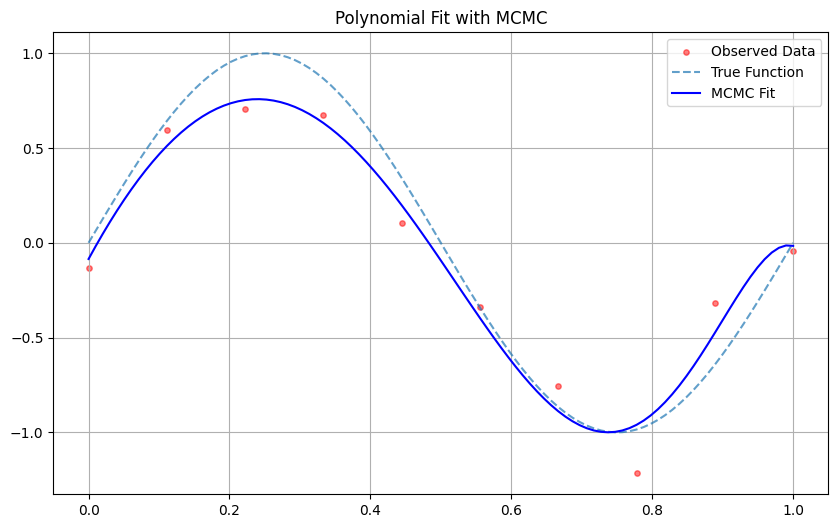

In [281]:
coeffs_samples = samples_mean
y_mean =    custom_function(x_plot, coeffs_samples)
plt.figure(figsize=(10, 6))
plt.scatter(x, y_obs, color='red', s=15, alpha=0.5, label="Observed Data")
plt.plot(x_plot, y_true, linestyle='--', alpha=0.7, label="True Function")
plt.plot(x_plot, y_mean, color='blue', label="MCMC Fit")
plt.title("Polynomial Fit with MCMC")
plt.legend()
plt.grid(True)
plt.show()

In [282]:
coeffs_samples_MAP = samples["coeffs"][MAP_sample_index_trace]


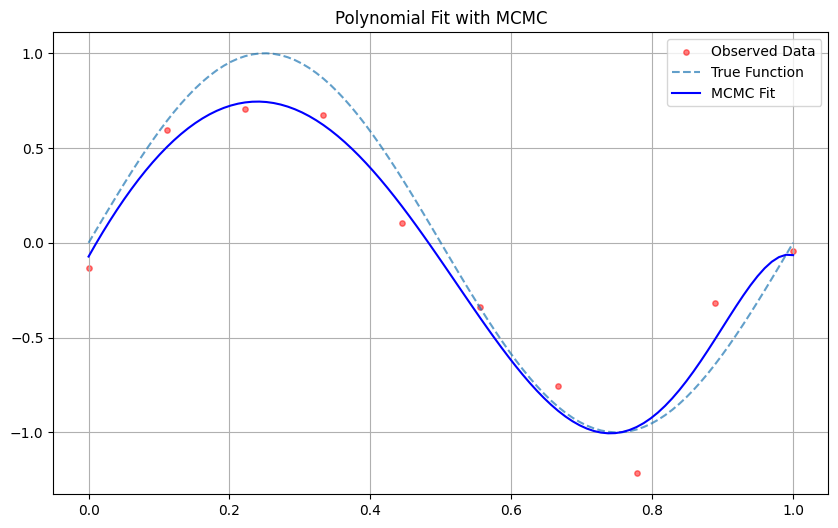

In [283]:

y_mean =    custom_function(x_plot, coeffs_samples_MAP)
plt.figure(figsize=(10, 6))
plt.scatter(x, y_obs, color='red', s=15, alpha=0.5, label="Observed Data")
plt.plot(x_plot, y_true, linestyle='--', alpha=0.7, label="True Function")
plt.plot(x_plot, y_mean, color='blue', label="MCMC Fit")
plt.title("Polynomial Fit with MCMC")
plt.legend()
plt.grid(True)
plt.show()